In [6]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Thêm thư mục cha (L02) vào sys.path
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

from src.models import stratified_k_fold_cross_validation

- Đầu vào của bài toán là các thông tin khách hàng tín dụng (các cột `Gender`, `Customer_Age`,...)
- Đầu ra của bài toán là tài khoản của khách hàng đã bị đóng/còn tồn tại (cột `Attrition_Flag`)
    - Cột `Attrition_Flag` chỉ có hai giá trị là `Attrited Customer` và `Existing Customer` dã được mã hóa thành `0` và `1`.
- Ta có: 
    - Mô hình `Logistic regression` là một mô hình phân loại (classification), chủ yếu dùng cho phân loại nhị phân: 2 lớp và trả về xác suất.
    - Mà yêu cầu bài toán cần phân loại tài khoản theo `0` và `1` (ở lại và không còn ở lại). <br>
➡ Mô hình `Logistic regression` là phù hợp.

Đọc dữ liệu đã tiền xử lí `data/processed/BankChurner.csv`

In [7]:
DATA_PATH = "../data/processed/BankChurners.csv"
data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
data.shape

(10127, 28)

Đầu ra là cột cuối cùng `Attrition_Flag` và các cột trước đó là đầu vào.

In [8]:
X = data[:, :-1]             # Đầu vào là tất cả các cột trừ cột cuối
y = data[:, -1].astype(int)  # Đầu ra là cột cuối cùng "Attrition_Flag"

print(f"X shape={X.shape}, y shape={y.shape}")

X shape=(10127, 27), y shape=(10127,)


- Với `x` là dữ liệu đầu vào và `y` là dữ liệu đầu ra.
- Sử dụng phương pháp `K-fold Cross-Validation`chia dữ liệu thành các fold. Trong mỗi lượt:
    - Dùng k - 1 fold để train.
    - Dùng 1 fold còn lại để test.

**Lưu ý**: Do dữ liệu đầu ra ở cột `Attrition_Flag` bị mất cân bằng. tỉ lệ đã tìm hiểu ở file `01_data_exploration.py`: <br>
    - `"Attrited Customer"`: $16.1\%$ <br>
    - `"Existing Customer"`: $83.9\%$

➡ sử dụng phiên bản cải tiến `Stratified K-Fold Cross-Validation` giảm sự mất cân bằng, cụ thể là:
- Mỗi fold được chia sao cho tỷ lệ các lớp trong fold giống với tỷ lệ tổng thể của dataset.
- Mỗi fold đều có tỉ lệ biến đầu ra $y = 1$ là $83.9\%$ và tỉ lệ $y = 0$ là $16.1\%$.

Hàm đánh giá (evaluation metrics) truyền vào 2 đại lượng đầu ra thật `y_true` và đầu ra dự đoán bởi mô hình `y_pred`:
- Gọi với mỗi fold chạy mô hình Logistic Regression và được đánh giá bằng bốn chỉ số chính: Accuracy, Precision, Recall và F1-Score:
    - `Accuracy`: Độ chính xác tổng thể
        $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
    - `Precision`: Trong số khách hàng dự đoán là rời đi, bao nhiêu là đúng. 
        $$\text{Precision} = \frac{TP}{TP + FP}$$
    - `Recall`: Trong số khách hàng rời đi, tìm được bao nhiêu.
        $$\text{Recall} = \frac{TP}{TP + FN}$$
    - `F1-Score`: Đây là trung bình điều hòa (harmonic mean) của Precision và Recall.
        $$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
    - Chú thích các đại lượng:
        - TP (True Positive)

            - Số lượng khách hàng thực sự đi (y_true = 1)

            - Và mô hình cũng dự đoán đi (y_pred = 1)

            - Đây là trường hợp phát hiện đúng khách sắp rời đi → rất quan trọng.

        - TN (True Negative)

            - Số lượng khách hàng thực sự ở lại (y_true = 0)

            - Và mô hình dự đoán ở lại (y_pred = 0)

            - Mô hình “yên tâm”, không kích hoạt hành động giữ chân → đúng.

        - FP (False Positive)

            - Khách thực sự ở lại (y_true = 0)

            - Nhưng mô hình dự đoán đi (y_pred = 1)

            - Nghĩa là báo động nhầm:

            - Hệ quả: Có thể nhầm nhưng không gây ra hậu quả.

        - FN (False Negative)

            - Khách thực sự đi (y_true = 1)

            - Nhưng mô hình dự đoán ở lại (y_pred = 0)

            - Đây là trường hợp nguy hiểm nhất:

            - Ngân hàng bỏ sót khách sắp rời đi → Gây ra hậu quả lớn.

Mô hình **Logistic Regression**, dùng **Batch Gradient Descent** để tối ưu hàm mất mát **Binary Cross-Entropy (Log Loss)**.

Mục tiêu:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

với:

* $\mathbf{w}$: vector trọng số (weights)
* $b$: bias
* $\sigma(z)$: hàm sigmoid - ánh xạ sang xác suất trong khoảng (0, 1)
    $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
    $$z = \mathbf{w}^T \mathbf{x} + b$$
Trong bài toán đặt ra:

* $y = 1$: khách hàng rời đi
* $y = 0$: khách hàng ở lại

Mô hình học bộ tham số $(\mathbf{w}, b)$ sao cho xác suất dự đoán $P(y = 1 \mid \mathbf{x})$ gần với nhãn thực tế.

Mô hình cung cấp hai dạng dự đoán: <br>
    - Xác suất khách hàng rời đi bằng hàm `predict_proba` dựa trên hàm `_sigmoid` -  $\sigma(z)$ <br>. 
    - Khách hàng thuộc loại ở lại/rời đi thông qua hàm `predict`. Đặt `threshold = 0.3` thấp để có thể 'bắt' được nhiều khách hàng sẽ rời đi hơn, giúp hạn chế việc bỏ lỡ khách hàng gây ra thiệt hại nhỏ hơn.

In [9]:
trained_model, accuracies, precisions, recalls, f1s = stratified_k_fold_cross_validation(
    X, y, k=5, learning_rate=0.1, num_iterations=2000)

Fold 1: Acc=0.8973, Precision=0.6595, Recall=0.7485, F1=0.7011
Fold 2: Acc=0.9047, Precision=0.6822, Recall=0.7638, F1=0.7207
Fold 3: Acc=0.8998, Precision=0.6640, Recall=0.7600, F1=0.7088
Fold 4: Acc=0.9141, Precision=0.7151, Recall=0.7723, F1=0.7426
Fold 5: Acc=0.8923, Precision=0.6404, Recall=0.7508, F1=0.6912

--- AVERAGE RESULTS ---
Accuracy :  0.9016
Precision:  0.6722
Recall   :  0.7591
F1-score :  0.7129


Vẽ biểu đố các đại lượng dùng để đánh giá của từng fold

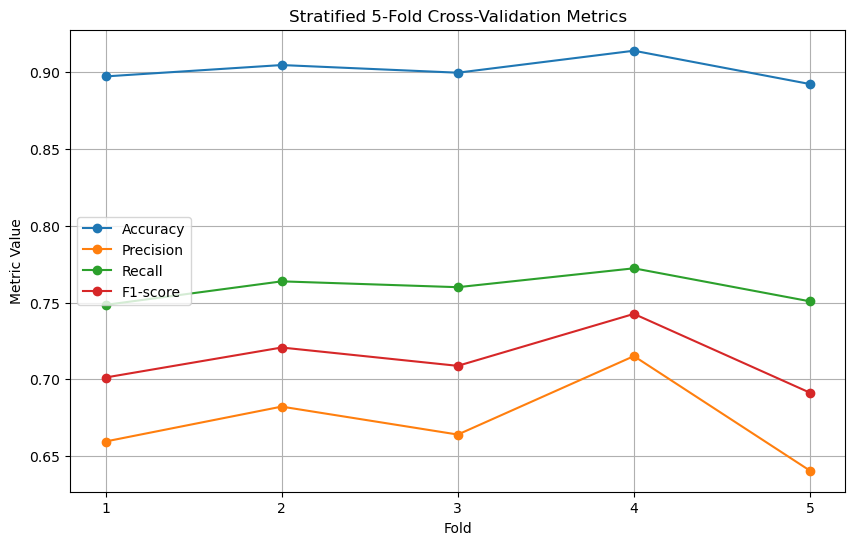

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [
    accuracies,
    precisions,
    recalls,
    f1s
]

plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.plot(range(1, len(values[i]) + 1), values[i], marker='o', label=metric)

plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Fold")
plt.ylabel("Metric Value")
plt.title("Stratified 5-Fold Cross-Validation Metrics")
plt.legend()
plt.grid(True)

plt.savefig("metrics_plot.png", bbox_inches="tight") 
plt.show()

➡️ **Nhận xét**:

🔍 `Accuracy`

- Accuracy của mô hình thường khá cao do dữ liệu bị mất cân bằng (84% khách ở lại).

- Accuracy không phải thước đo quan trọng nhất vì mô hình có thể dự đoán toàn bộ “không churn” vẫn đạt điểm cao.

🔍 `Precision`

- Precision phản ánh chất lượng dự đoán khách có rời đi hay không.

- Precision cao nghĩa là mô hình ít báo động nhầm → không bị tốn chi phí giữ chân sai đối tượng.

🔍 `Recall` (Quan trọng nhất)

- Recall thể hiện khả năng mô hình bắt đúng khách churn thật.

- Nếu Recall thấp → mô hình bỏ sót khách rời đi → gây thiệt hại lớn trong kinh doanh.

🔍 `F1-score`

- Là trung bình điều hòa của Precision và Recall → cân bằng 2 yếu tố.

- F1-score cao cho thấy mô hình hoạt động ổn định và phù hợp cho bài toán trên.